<a href="https://colab.research.google.com/github/bhushan1729/Pytorch-Tutorial/blob/colab-upload/U_NET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from torchvision.datasets import OxfordIIITPet
import torchvision.transforms as T
from torch.utils.data import Dataset
from PIL import Image

In [2]:
class OxfordPetsSegmentation(Dataset):
  def __init__(self, root='.', split='trainval', image_size=128):
    self.dataset = OxfordIIITPet(root, split=split, download=True, target_types='segmentation')
    self.images = self.dataset._images
    self.masks = self.dataset._segs
    total = len(self.images)
    if split == 'train':
      self.images = self.images[:int(0.8 * total)]
      self.masks = self.masks[:int(0.8 * total)]
    else:
      self.images = self.images[int(0.8 * total):]
      self.masks = self.masks[int(0.8 * total):]

    self.img_transform = T.Compose([T.Resize((image_size, image_size)), T.ToTensor()])
    self.mask_transform = T.Compose([T.Resize((image_size, image_size), interpolation=Image.NEAREST), T.PILToTensor()])

  def __len__(self):
     return len(self.images)

  def __getitem__(self, idx):
     image = Image.open(self.images[idx]).convert('RGB')
     mask = Image.open(self.masks[idx])
     img = self.img_transform(image)
     mask = self.mask_transform(mask).squeeze(0) - 1
     return img, mask.long()

In [10]:
import matplotlib.pyplot as plt
import torch

In [11]:
dataset = OxfordPetsSegmentation(root='.', split='trainval', image_size=128)
img, mask = dataset[0]

In [16]:
len(dataset)

736

In [17]:
dataset[0]

(tensor([[[0.4431, 0.5804, 0.5804,  ..., 0.7137, 0.7686, 0.7843],
          [0.3686, 0.4549, 0.5059,  ..., 0.7529, 0.7490, 0.7373],
          [0.3529, 0.3765, 0.4235,  ..., 0.6902, 0.6863, 0.7020],
          ...,
          [0.4667, 0.4039, 0.2902,  ..., 0.4784, 0.4196, 0.4392],
          [0.4941, 0.3373, 0.3647,  ..., 0.4157, 0.4549, 0.3647],
          [0.5255, 0.4275, 0.4039,  ..., 0.4784, 0.3804, 0.4510]],
 
         [[0.5804, 0.6392, 0.6118,  ..., 0.5686, 0.6392, 0.6549],
          [0.5490, 0.5608, 0.5098,  ..., 0.6118, 0.6196, 0.6039],
          [0.5725, 0.5608, 0.4941,  ..., 0.5333, 0.5373, 0.5529],
          ...,
          [0.6588, 0.5647, 0.5647,  ..., 0.7216, 0.6000, 0.6392],
          [0.7216, 0.5882, 0.6078,  ..., 0.6471, 0.6196, 0.5686],
          [0.7216, 0.6745, 0.6588,  ..., 0.6784, 0.5843, 0.6314]],
 
         [[0.4706, 0.5529, 0.4980,  ..., 0.5255, 0.6000, 0.6392],
          [0.3804, 0.4471, 0.4078,  ..., 0.5804, 0.5961, 0.5843],
          [0.3569, 0.3569, 0.3804,  ...,

In [18]:
img, mask = dataset[0]    # this internally calls dataset.__getitem__(0)

print("Image shape:", img.shape)
print("Mask shape:", mask.shape)

Image shape: torch.Size([3, 128, 128])
Mask shape: torch.Size([128, 128])


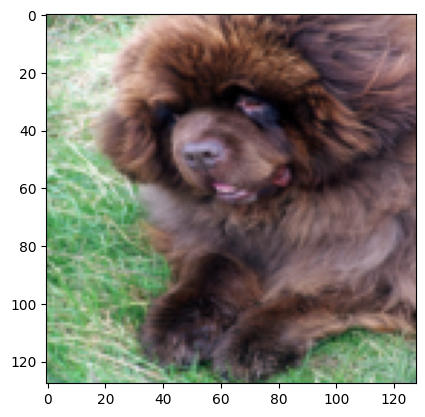

In [25]:
img_np = img.permute(1, 2, 0).numpy()
plt.imshow(img_np)

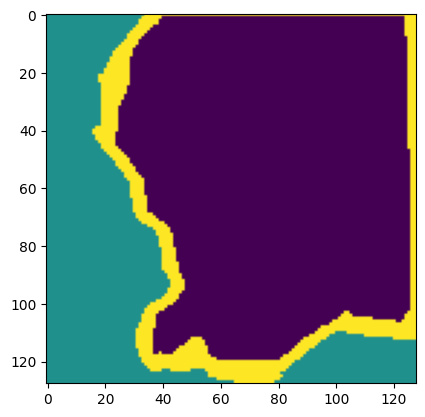

In [24]:
mask_np = mask.numpy()
plt.imshow(mask_np)

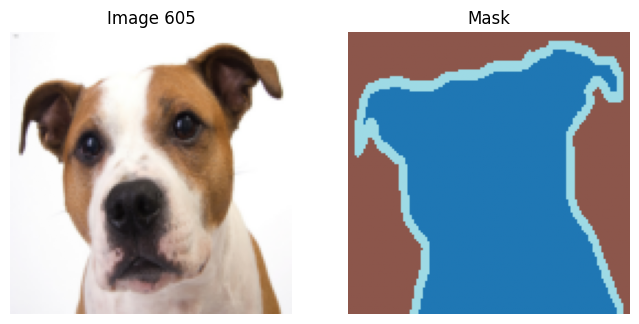

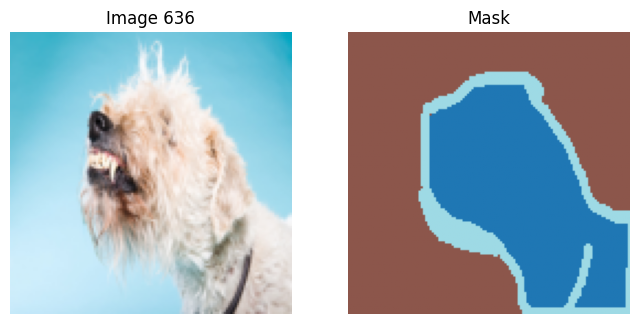

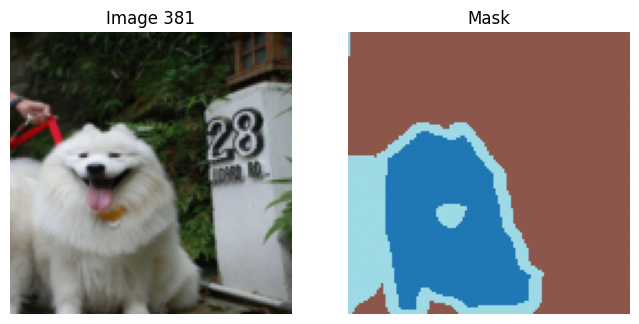

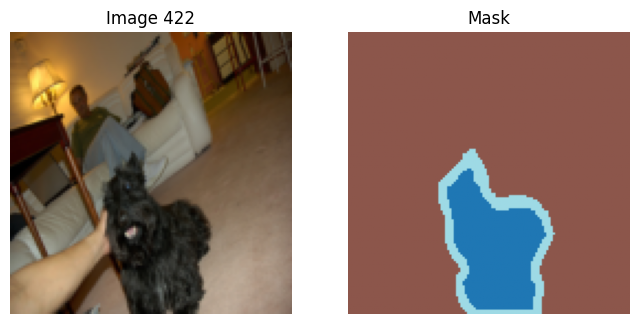

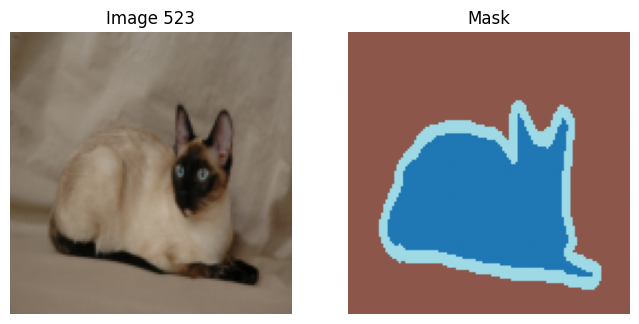

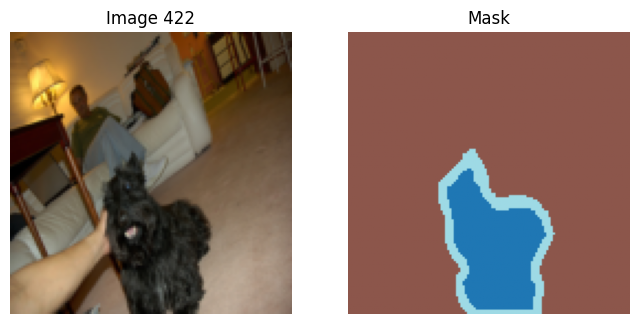

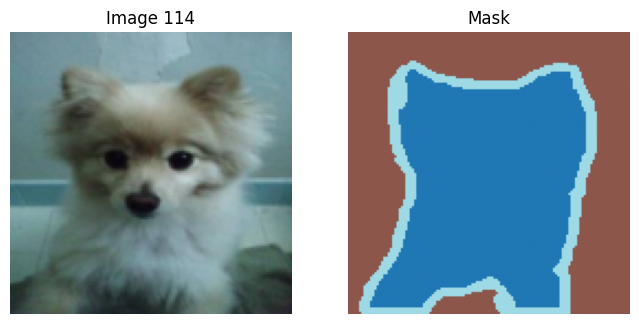

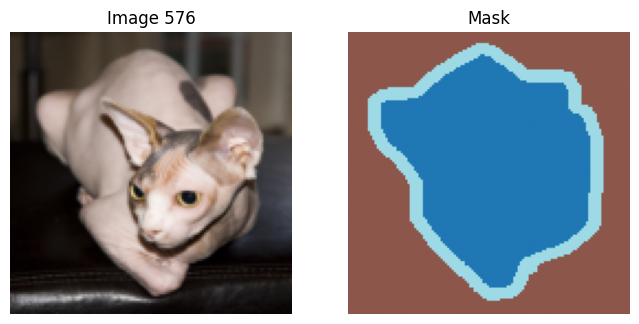

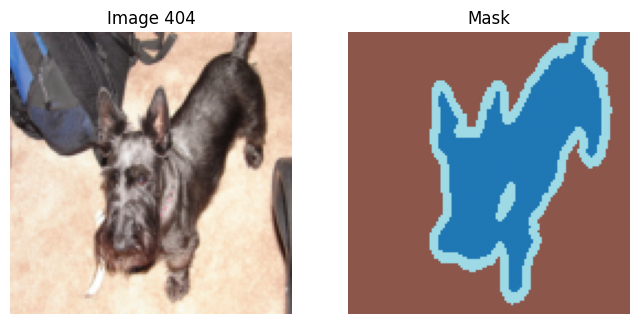

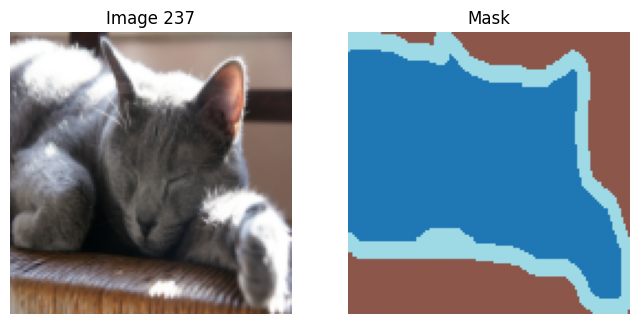

In [28]:
import random

for i in range(10):
    idx = random.randint(0, len(dataset)-1)
    img, mask = dataset[idx]
    img_np = img.permute(1, 2, 0).numpy()
    mask_np = mask.numpy()

    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(img_np)
    plt.title(f"Image {idx}")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(mask_np, cmap='tab20')
    plt.title("Mask")
    plt.axis("off")

    plt.show()


In [3]:
import torch
import torch.nn as nn

class UNet(nn.Module):
  def __init__(self, in_channels=3, out_classes=3):
    super().__init__()

    def conv_block(in_ch, out_ch):
      return nn.Sequential(
          nn.Conv2d(in_ch, out_ch, 3, padding=1), # kernel size = 3
          nn.ReLU(inplace=True),
          nn.Conv2d(out_ch, out_ch, 3, padding=1),
          nn.ReLU(inplace=True)
      )

    self.enc1 = conv_block(in_channels, 64)
    self.pool1 = nn.MaxPool2d(2)

    self.enc2 = conv_block(64, 128)
    self.pool2 = nn.MaxPool2d(2)

    self.enc3 = conv_block(128, 256)
    self.pool3 = nn.MaxPool2d(2)

    self.enc4 = conv_block(256, 512)
    self.pool4 = nn.MaxPool2d(2)

    self.bottleneck = conv_block(512, 1024)

    self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
    self.dec4 = conv_block(1024, 512)

    self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
    self.dec3 = conv_block(512, 256)

    self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
    self.dec2 = conv_block(256, 128)

    self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
    self.dec1 = conv_block(128, 64)

    self.final = nn.Conv2d(64, out_classes, kernel_size=1)

  def forward(self, x):
    # input (1, 3, 128, 128)
    e1 = self.enc1(x)                   # e1 = (1, 64, 128, 128)
    e2 = self.enc2(self.pool1(e1))      # e2 = (1, 128, 64, 64)
    e3 = self.enc3(self.pool2(e2))      # e3 = (1, 256, 32, 32)
    e4 = self.enc4(self.pool3(e3))      # e4 = (1, 512, 16, 16)
    b = self.bottleneck(self.pool4(e4)) # e5 = (1, 1024, 8, 8)

    d4 = self.up4(b)                     # d4 = (1, 512, 16, 16)
    d4 = torch.cat([e4, d4], dim=1)      # d4 = d4+e4 - d4 = (1, 1024, 16, 16)
    d4 = self.dec4(d4)                   # d4 = (1, 512, 16, 16)

    d3 = self.up3(d4)                    # d3 = (1, 256, 32, 32)
    d3 = torch.cat([e3, d3], dim=1)      # d3 = d3+e3 - d3 = (1, 512, 32, 32)
    d3 = self.dec3(d3)                   # d3 = (1, 256, 32, 32)

    d2 = self.up2(d3)                    # d2 = (1, 128, 64, 64)
    d2 = torch.cat([d2, e2], dim=1)      # d2 = d2+e2 - d2 = (1, 256, 64, 64)
    d2 = self.dec2(d2)                   # d2 = (1, 128, 64, 64)

    d1 = self.up1(d2)                    # d1 = (1, 64, 128, 128)
    d1 = torch.cat([d1, e1], dim=1)      # d1 = d1+e1 - d1 = (1, 128, 128, 128)
    d1 = self.dec1(d1)                   # d1 = (1, 64, 128, 128)

    return self.final(d1)                # (1, 3, 128, 128) same size as image but it's mask

In [8]:
from torch.utils.data import Dataset, DataLoader

train_data = OxfordPetsSegmentation(split='trainval')
train_loader = DataLoader(train_data, batch_size=8, shuffle=True)
model = UNet(in_channels=3, out_classes=3).cuda()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

losses = []
for epoch in range(50):
  model.train()
  running_loss = 0
  for x, y in train_loader:
    x, y = x.cuda(), y.cuda()
    optimizer.zero_grad()
    pred = model(x)
    loss = loss_fn(pred, y)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
  avg = running_loss / len(train_loader)
  losses.append(avg)
  print(f"Epoch: {epoch}, Loss: {avg}")

Epoch: 0, Loss: 0.9372199216614598
Epoch: 1, Loss: 0.8140469944995382
Epoch: 2, Loss: 0.7311739079330278
Epoch: 3, Loss: 0.7135832478170809
Epoch: 4, Loss: 0.6670222444378812
Epoch: 5, Loss: 0.673299962411756
Epoch: 6, Loss: 0.6710868335288503
Epoch: 7, Loss: 0.6644046339003936
Epoch: 8, Loss: 0.6452791554772336
Epoch: 9, Loss: 0.6369993310907612
Epoch: 10, Loss: 0.6251347826226897
Epoch: 11, Loss: 0.6163005368865054
Epoch: 12, Loss: 0.5965259493045185
Epoch: 13, Loss: 0.5953359435433927
Epoch: 14, Loss: 0.5800596495037493
Epoch: 15, Loss: 0.5662484071824861
Epoch: 16, Loss: 0.5940991588260817
Epoch: 17, Loss: 0.5435824669573618
Epoch: 18, Loss: 0.5236351648750512
Epoch: 19, Loss: 0.5152014066343722
Epoch: 20, Loss: 0.504280582394289
Epoch: 21, Loss: 0.4866977573736854
Epoch: 22, Loss: 0.47501644232998724
Epoch: 23, Loss: 0.4584450404281202
Epoch: 24, Loss: 0.4475023853390113
Epoch: 25, Loss: 0.42641710522382154
Epoch: 26, Loss: 0.4327462503443594
Epoch: 27, Loss: 0.43000554131424945
E

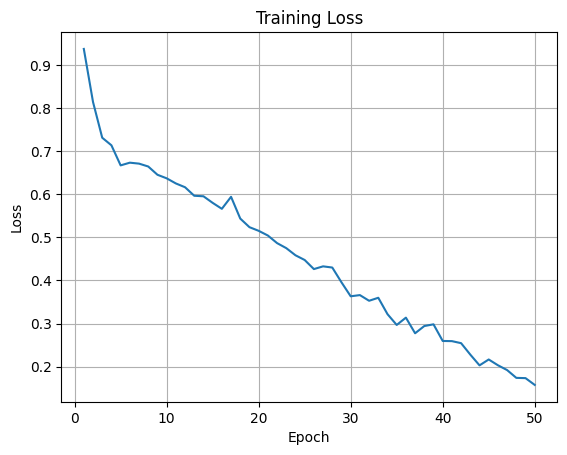

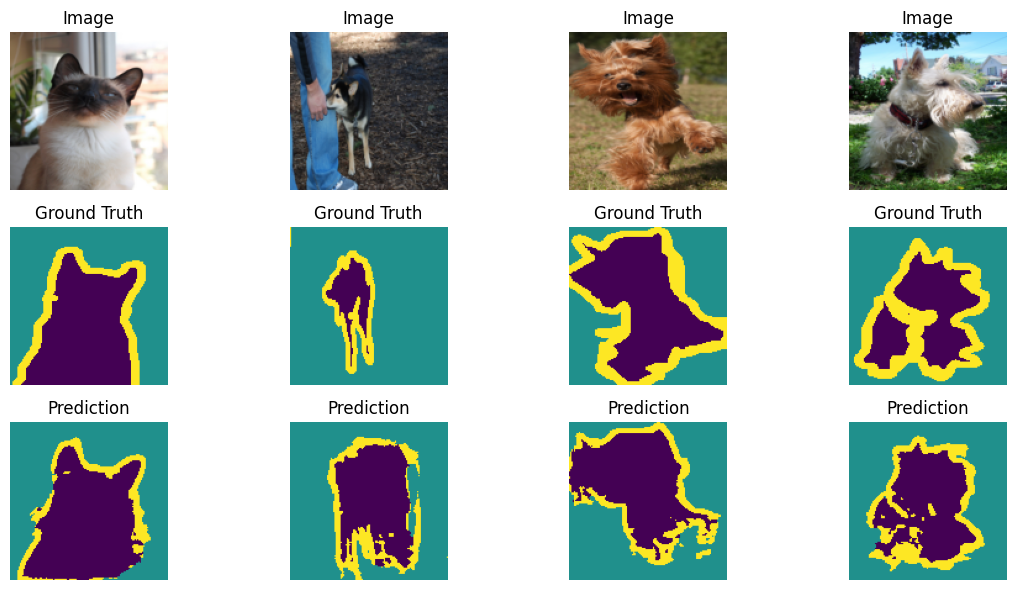

In [11]:
import matplotlib.pyplot as plt

plt.plot(range(1,51), losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()


# Visualize predictions
test_data = OxfordPetsSegmentation(split='test')
test_loader = DataLoader(test_data, batch_size=4, shuffle=True)
x, y = next(iter(test_loader))
x = x.cuda()
with torch.no_grad():
  model.eval()
  pred = torch.argmax(model(x), dim=1).cpu()

# Plot

fig, axes = plt.subplots(3, 4, figsize=(12,6))
for i in range(4):
  axes[0, i].imshow(x[i].permute(1,2,0).cpu())
  axes[1, i].imshow(y[i])
  axes[2, i].imshow(pred[i])
  axes[0, i].set_title("Image")
  axes[1, i].set_title("Ground Truth")
  axes[2, i].set_title("Prediction")
  for j in range(3): axes[j, i].axis("off")
plt.tight_layout()
plt.show()